# RQ1 Answer: Modality-Dependent Temporal Genre Evolution (Euclidean Distance)

**RQ1:** How much do music genres change over time across acoustic, visual, and lyrical feature modalities?

This notebook is the Euclidean-distance inspection and interpretation notebook for RQ1. The calculation-heavy steps are expected to be done by:

```bash
python src/04_answer_RQ1_calculate_drift.py
```

The notebook loads the saved drift outputs, creates the main RQ1 plots and tables, and provides a compact structure for answering the research question.

## Load Libraries And Paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from helper_functions import PROCESSED_DIR
except ImportError:
    PROJECT_ROOT = Path.cwd()

    PROJECT_ROOT = PROJECT_ROOT.parent.parent.parent

    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

CENTROID_DIR = PROCESSED_DIR / "03_ortools_centroids"
DRIFT_DIR = PROCESSED_DIR / "04_ortools_centroid_drift"
PLOTS_DIR = PROJECT_ROOT / "plots" / "RQ1_answer"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Centroid directory:", CENTROID_DIR)
print("Drift directory:", DRIFT_DIR)
print("Plots directory:", PLOTS_DIR)

Centroid directory: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/03_ortools_centroids
Drift directory: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/04_ortools_centroid_drift
Plots directory: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer


## Load RQ1 Drift Outputs

In [2]:
drift_wpz = pd.read_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_wpz.parquet"
)

drift_wpz_neighbors = pd.read_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_wpz_neighbors.parquet"
)

drift_raw = pd.read_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_raw.parquet"
)

drift_raw_neighbors = pd.read_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_raw_neighbors.parquet"
)

modality_summary = pd.read_csv(
    DRIFT_DIR / "rq1_modality_drift_summary_wpz_neighbors.csv"
)

genre_drift_summary = pd.read_csv(
    DRIFT_DIR / "rq1_genre_drift_summary_wpz_neighbors.csv"
)

landscape_drift = pd.read_parquet(
    DRIFT_DIR / "rq1_selected_genre_landscape_drift_wpz_neighbors.parquet"
)

raw_vs_wpz_summary = pd.read_csv(
    DRIFT_DIR / "rq1_raw_vs_wpz_drift_summary.csv"
)

modalities = sorted(drift_wpz_neighbors["modality"].unique())

print("Modalities:", modalities)
print("WPZ neighboring transitions:", drift_wpz_neighbors.shape)
print("Raw neighboring transitions:", drift_raw_neighbors.shape)

Modalities: ['essentia', 'lyrics_tf_idf', 'mfcc', 'musicnn', 'vgg19', 'word2vec']
WPZ neighboring transitions: (12670, 12)
Raw neighboring transitions: (12670, 12)


## Main RQ1 Summary Table

In [3]:
main_summary = modality_summary[
    [
        "modality",
        "n_transitions",
        "n_genres",
        "mean_euclidean_distance",
        "median_euclidean_distance",
        "std_euclidean_distance",
        "mean_cosine_distance",
        "median_cosine_distance",
        "median_tracks_t",
        "median_tracks_t1",
    ]
].copy()

main_summary = main_summary.sort_values(
    "mean_euclidean_distance",
    ascending=False,
)

main_summary


,modality,n_transitions,n_genres,mean_euclidean_distance,median_euclidean_distance,std_euclidean_distance,mean_cosine_distance,median_cosine_distance,median_tracks_t,median_tracks_t1
1,vgg19,2040,50,8.123186,7.972392,1.598305,0.106170,0.110277,99.5,107.5
4,essentia,2126,50,2.338798,2.344472,0.455970,0.054254,0.046670,112.0,116.0
0,lyrics_tf_idf,2126,50,2.337153,2.242259,0.566745,0.138956,0.144210,112.0,116.5
2,word2vec,2126,50,1.305929,1.243031,0.297457,0.063515,0.062850,112.0,116.5
3,mfcc,2126,50,0.773923,0.776803,0.214601,0.055637,0.047847,112.0,116.5
5,musicnn,2126,50,0.536921,0.496839,0.173512,0.025686,0.020989,112.0,116.5


## Rank Modalities By Average Drift

In [4]:
ranking = main_summary[
    [
        "modality",
        "mean_euclidean_distance",
        "median_euclidean_distance",
        "mean_cosine_distance",
    ]
].reset_index(drop=True)

ranking.index = ranking.index + 1
ranking


,modality,mean_euclidean_distance,median_euclidean_distance,mean_cosine_distance
1,vgg19,8.123186,7.972392,0.106170
2,essentia,2.338798,2.344472,0.054254
3,lyrics_tf_idf,2.337153,2.242259,0.138956
4,word2vec,1.305929,1.243031,0.063515
5,mfcc,0.773923,0.776803,0.055637
6,musicnn,0.536921,0.496839,0.025686


## Plot Mean Drift By Modality

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_average_drift_by_modality_euclidean.png


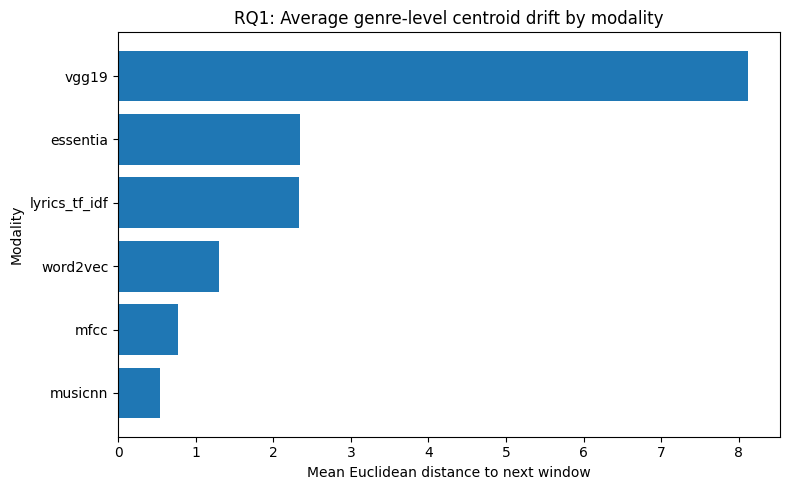

In [5]:
plot_data = main_summary.sort_values("mean_euclidean_distance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    plot_data["modality"],
    plot_data["mean_euclidean_distance"],
)
plt.xlabel("Mean Euclidean distance to next window")
plt.ylabel("Modality")
plt.title("RQ1: Average genre-level centroid drift by modality")
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_average_drift_by_modality_euclidean.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Plot Drift Distributions Across Modalities

/tmp/ipykernel_1798123/708739747.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_drift_distribution_by_modality_euclidean.png


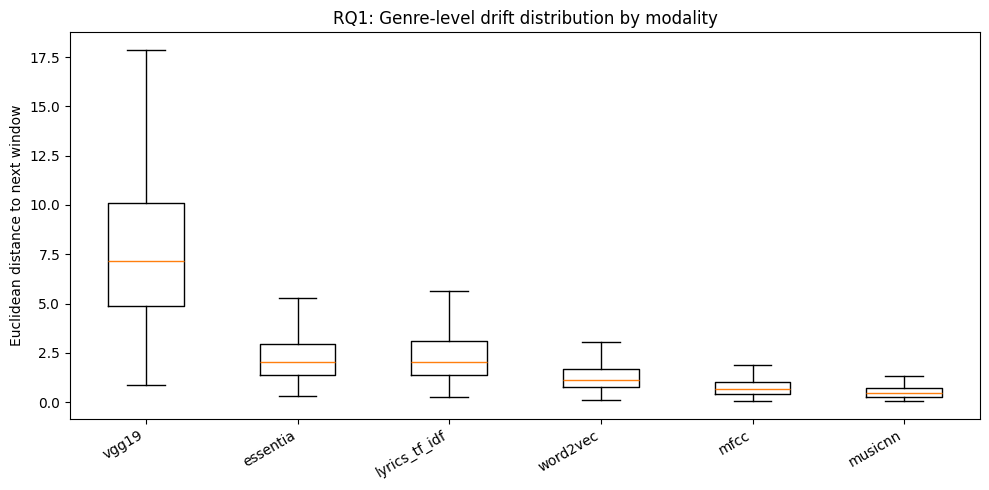

In [6]:
ordered_modalities = main_summary["modality"].tolist()

boxplot_data = [
    drift_wpz_neighbors.loc[
        drift_wpz_neighbors["modality"] == modality,
        "euclidean_distance",
    ].dropna()
    for modality in ordered_modalities
]

plt.figure(figsize=(10, 5))
plt.boxplot(
    boxplot_data,
    labels=ordered_modalities,
    showfliers=False,
)
plt.ylabel("Euclidean distance to next window")
plt.title("RQ1: Genre-level drift distribution by modality")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_drift_distribution_by_modality_euclidean.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Plot Drift Over Time

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_mean_drift_over_time_euclidean.png


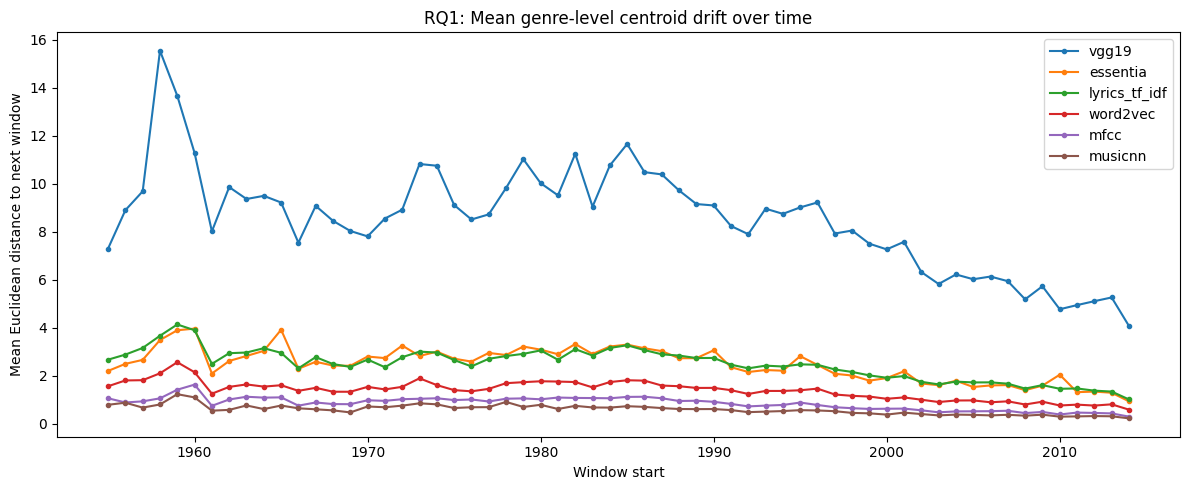

In [7]:
# Calculate per-genre drift first, then weight genres equally.
genre_drift_over_time = (
    drift_wpz_neighbors
    .groupby(["modality", "window_start", "genre"], as_index=False)
    .agg(genre_mean_euclidean_distance=("euclidean_distance", "mean"))
)

drift_over_time = (
    genre_drift_over_time
    .groupby(["modality", "window_start"], as_index=False)
    .agg(
        mean_euclidean_distance=("genre_mean_euclidean_distance", "mean"),
        median_euclidean_distance=("genre_mean_euclidean_distance", "median"),
        n_genres=("genre", "nunique"),
    )
)

plt.figure(figsize=(12, 5))

for modality in ordered_modalities:
    data = drift_over_time[drift_over_time["modality"] == modality]

    plt.plot(
        data["window_start"],
        data["mean_euclidean_distance"],
        marker="o",
        markersize=3,
        label=modality,
    )

plt.xlabel("Window start")
plt.ylabel("Mean Euclidean distance to next window")
plt.title("RQ1: Mean genre-level centroid drift over time")
plt.legend()
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_mean_drift_over_time_euclidean.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Compare Genre Drift With Selected-Genre Landscape Baseline

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_genre_drift_vs_landscape_baseline_euclidean.png


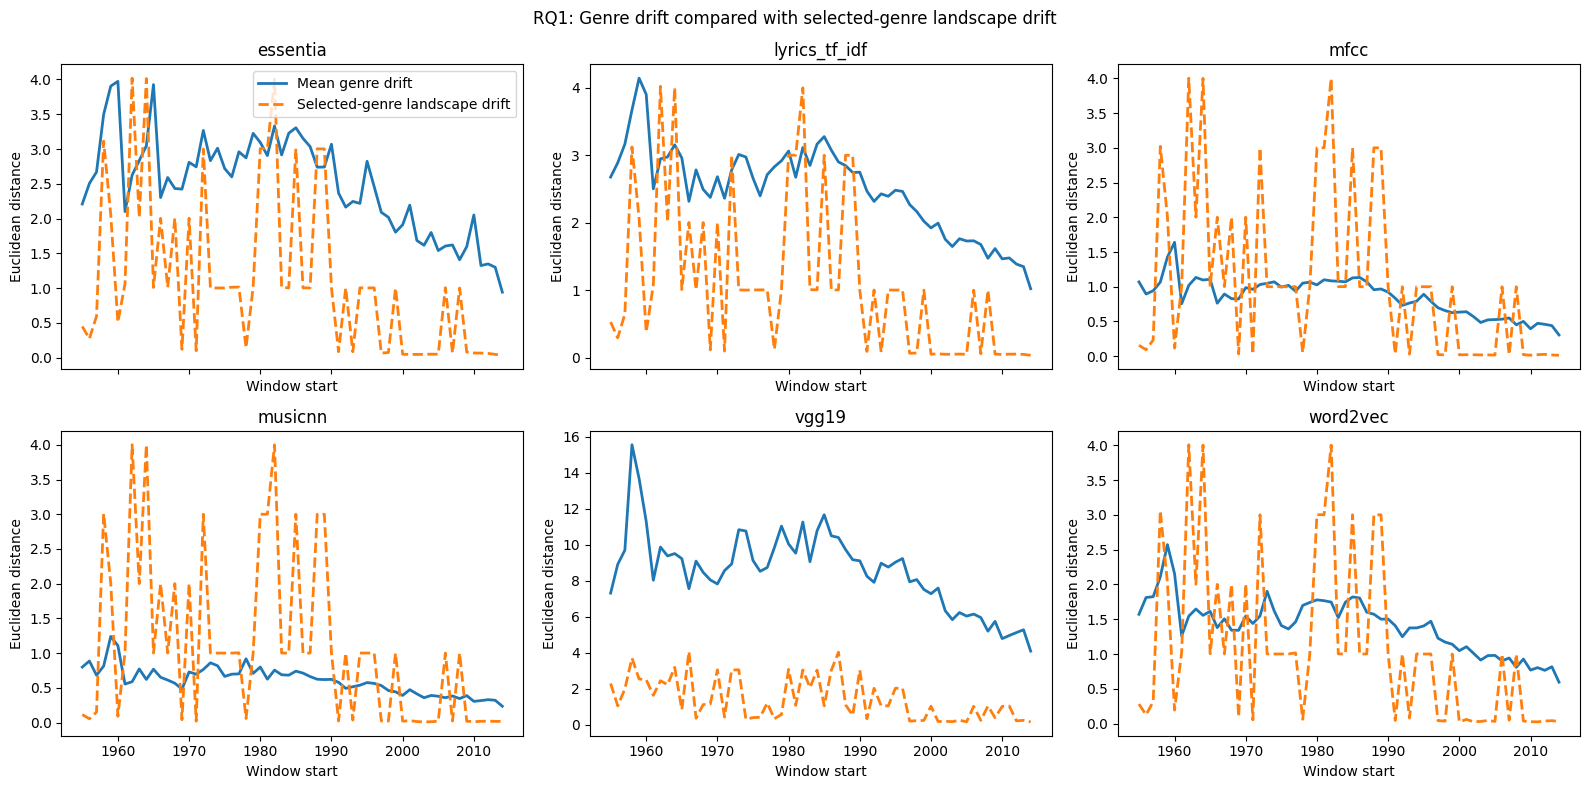

In [8]:
genre_drift_by_window = (
    drift_wpz_neighbors
    .groupby(["modality", "window_start", "genre"], as_index=False)
    .agg(genre_mean_euclidean_distance=("euclidean_distance", "mean"))
)

genre_time = (
    genre_drift_by_window
    .groupby(["modality", "window_start"], as_index=False)
    .agg(mean_genre_euclidean_distance=("genre_mean_euclidean_distance", "mean"))
)

baseline_time = landscape_drift[
    ["modality", "window_start", "euclidean_distance"]
].rename(columns={"euclidean_distance": "landscape_euclidean_distance"})

baseline_comparison = genre_time.merge(
    baseline_time,
    on=["modality", "window_start"],
    how="left",
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for ax, modality in zip(axes, modalities):
    data = baseline_comparison[
        baseline_comparison["modality"] == modality
    ].sort_values("window_start")

    ax.plot(
        data["window_start"],
        data["mean_genre_euclidean_distance"],
        label="Mean genre drift",
        linewidth=2,
    )
    ax.plot(
        data["window_start"],
        data["landscape_euclidean_distance"],
        label="Selected-genre landscape drift",
        linewidth=2,
        linestyle="--",
    )

    ax.set_title(modality)
    ax.set_xlabel("Window start")
    ax.set_ylabel("Euclidean distance")

axes[0].legend()
fig.suptitle("RQ1: Genre drift compared with selected-genre landscape drift")
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_genre_drift_vs_landscape_baseline_euclidean.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Summarize Landscape Baseline Difference

In [9]:
baseline_summary = (
    baseline_comparison
    .groupby("modality")
    .agg(
        mean_genre_euclidean_distance=("mean_genre_euclidean_distance", "mean"),
        mean_landscape_euclidean_distance=("landscape_euclidean_distance", "mean"),
    )
    .reset_index()
)

baseline_summary["genre_minus_landscape"] = (
    baseline_summary["mean_genre_euclidean_distance"]
    - baseline_summary["mean_landscape_euclidean_distance"]
)

baseline_summary.sort_values("genre_minus_landscape", ascending=False)

,modality,mean_genre_euclidean_distance,mean_landscape_euclidean_distance,genre_minus_landscape
4,vgg19,8.550535,1.419339,7.131196
1,lyrics_tf_idf,2.497875,1.126692,1.371183
0,essentia,2.495770,1.128387,1.367383
5,word2vec,1.409099,1.100493,0.308606
2,mfcc,0.857743,1.085672,-0.227929
3,musicnn,0.604838,1.081405,-0.476567


## Identify Highest-Drift Genres Per Modality

In [10]:
top_n = 10

top_drifting_genres = (
    genre_drift_summary
    .sort_values(
        ["modality", "mean_euclidean_distance"],
        ascending=[True, False],
    )
    .groupby("modality")
    .head(top_n)
    .reset_index(drop=True)
)

top_drifting_genres

,modality,genre,n_transitions,mean_cosine_distance,median_cosine_distance,mean_euclidean_distance,median_euclidean_distance,median_tracks_t,median_tracks_t1
0,essentia,bossa nova,52,0.039617,0.032591,3.305689,3.310314,37.0,39.0
1,essentia,experimental,51,0.110943,0.086651,3.163517,2.718116,37.0,38.0
2,essentia,easy listening,44,0.065351,0.047831,2.913382,2.750812,31.5,32.0
3,essentia,soft rock,48,0.102533,0.077291,2.911739,2.734413,42.0,42.5
4,essentia,glam rock,34,0.112152,0.099426,2.892782,2.879982,28.5,28.5
5,essentia,ambient,41,0.019752,0.012212,2.846997,2.538109,165.0,179.0
6,essentia,electronic,44,0.056704,0.020706,2.826165,1.862167,176.0,219.5
7,essentia,black metal,35,0.020488,0.011157,2.804443,2.334271,147.0,155.0
8,essentia,hardcore punk,29,0.031507,0.021693,2.795489,2.527482,34.0,35.0
9,essentia,folk,56,0.035447,0.023208,2.791784,2.631067,40.0,41.5


## Plot Highest-Drift Genres For One Modality

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_answer/rq1_top_drifting_genres_euclidean_word2vec.png


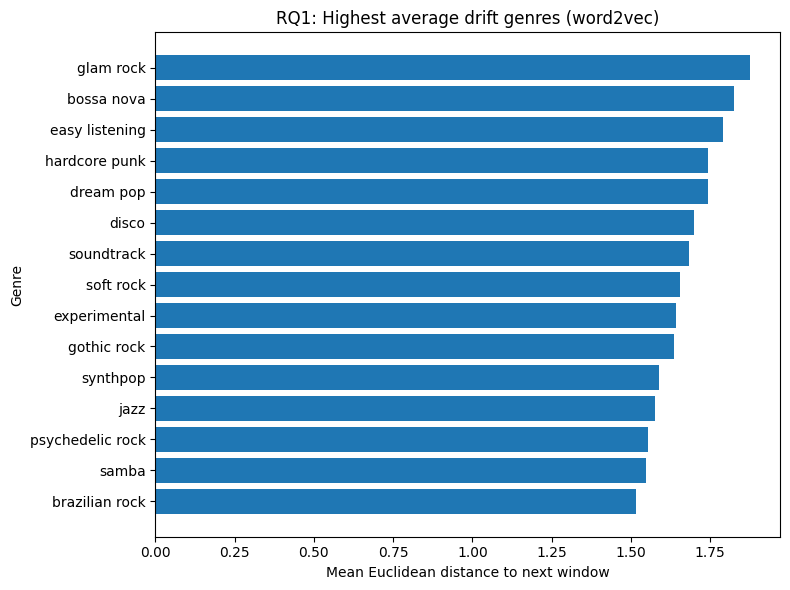

In [11]:
selected_modality = "word2vec"
top_n = 15

plot_data = (
    genre_drift_summary[genre_drift_summary["modality"] == selected_modality]
    .sort_values("mean_euclidean_distance", ascending=True)
    .tail(top_n)
)

plt.figure(figsize=(8, 6))
plt.barh(plot_data["genre"], plot_data["mean_euclidean_distance"])
plt.xlabel("Mean Euclidean distance to next window")
plt.ylabel("Genre")
plt.title(f"RQ1: Highest average drift genres ({selected_modality})")
plt.tight_layout()

output_path = PLOTS_DIR / f"rq1_top_drifting_genres_euclidean_{selected_modality}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Check Whether Drift Is Driven By Few Extreme Genres

In [12]:
genre_variation = (
    genre_drift_summary
    .groupby("modality")
    .agg(
        mean_of_genre_means=("mean_euclidean_distance", "mean"),
        median_of_genre_means=("mean_euclidean_distance", "median"),
        p90_of_genre_means=("mean_euclidean_distance", lambda values: values.quantile(0.90)),
        max_of_genre_means=("mean_euclidean_distance", "max"),
    )
    .reset_index()
)

genre_variation["max_to_median_ratio"] = (
    genre_variation["max_of_genre_means"]
    / genre_variation["median_of_genre_means"]
)

genre_variation.sort_values("mean_of_genre_means", ascending=False)

,modality,mean_of_genre_means,median_of_genre_means,p90_of_genre_means,max_of_genre_means,max_to_median_ratio
4,vgg19,8.123186,7.972392,9.920742,12.440655,1.560467
0,essentia,2.338798,2.344472,2.851576,3.305689,1.409993
1,lyrics_tf_idf,2.337153,2.242259,3.158399,3.645915,1.626001
5,word2vec,1.305929,1.243031,1.704200,1.876251,1.509416
2,mfcc,0.773923,0.776803,1.052875,1.357577,1.747647
3,musicnn,0.536921,0.496839,0.786163,0.983522,1.979560


## Compare Raw And Within-Period Normalized Drift

In [13]:
raw_vs_wpz_summary[
    [
        "modality",
        "wpz_mean_euclidean_distance",
        "wpz_median_euclidean_distance",
        "raw_mean_euclidean_distance",
        "raw_median_euclidean_distance",
        "wpz_mean_cosine_distance",
        "raw_mean_cosine_distance",
    ]
].sort_values("wpz_mean_euclidean_distance", ascending=False)


,modality,wpz_mean_euclidean_distance,wpz_median_euclidean_distance,raw_mean_euclidean_distance,raw_median_euclidean_distance,wpz_mean_cosine_distance,raw_mean_cosine_distance
4,vgg19,8.123186,7.972392,7.891632,6.967401,0.106170,0.004640
0,essentia,2.338798,2.344472,145670.192883,80367.377169,0.054254,0.001970
1,lyrics_tf_idf,2.337153,2.242259,0.067959,0.060119,0.138956,0.041745
5,word2vec,1.305929,1.243031,0.017987,0.015515,0.063515,0.001605
2,mfcc,0.773923,0.776803,17.155774,14.223112,0.055637,0.001099
3,musicnn,0.536921,0.496839,0.037926,0.031194,0.025686,0.002663


## Notes And Limitations

- The main comparison uses within-period z-normalized centroids and Euclidean distance, so the result describes the magnitude of relative genre movement within the feature distribution of the same period.
- Euclidean distance captures changes in feature profile direction. Euclidean distance also captures displacement magnitude and is more sensitive to feature dimensionality.
- The analysis uses neighboring sliding windows with one-year hops. For statistical testing, non-overlapping windows or temporal-dependence-aware methods should be used.
- VGG19 may have slightly lower coverage than the other modalities because visual features are not available for all tracks.
- The selected-genre landscape baseline is based on the OR-Tools selected genre set, not the complete track-level dataset.